In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

from StockPathSimulation import StockPathSimulation
from StrategySimulation import StrategySimulation

### Simulation of Stock Paths

In [3]:
t = 1
nSims = 10
nSteps = 2000
sps = StockPathSimulation(expirationTime = t,
                          numOfSims = nSims,
                          numOfSteps = nSteps)

Let $W(t)$ denote the Brownian motion process. Then, for any partition $0 = t_0 < t_1 < \dotsb < t_n$, the increments
\begin{equation*}
W(t_1) = W(t_1) - W(t_0), \dotsc, W(t_n) - W(t_{n-1})
\end{equation*}
are independent and each increment is normally distributed with
\begin{equation*}
\mathbb{E}(W(t_{i+1}) - W(t_i)) = 0 \hspace{10pt} \text{ and } \hspace{10pt}  Var(W(t_{i+1}) - W(t_i))= t_{i+1} - t_i.
\end{equation*}

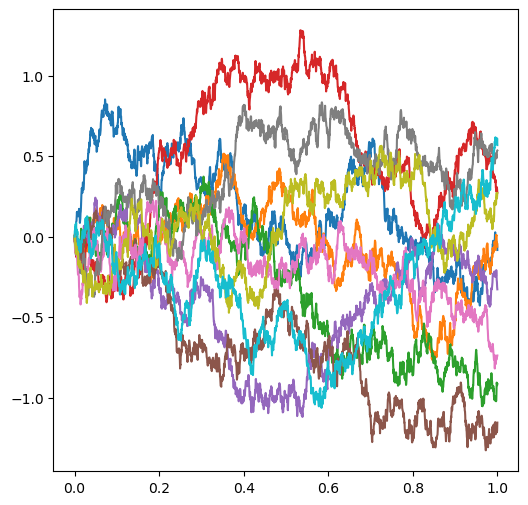

In [5]:
process = sps.simBrownianMotionProcess()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process,ax)

plt.show()

The geometric Brownian motion with mean rate of return $\alpha$ and volatility $\sigma$ is given by
\begin{equation*}
S(t) = S(0) \exp \left ( \sigma W(t) + (\alpha - \frac{1}{2}\sigma^2) t\right )
\end{equation*}

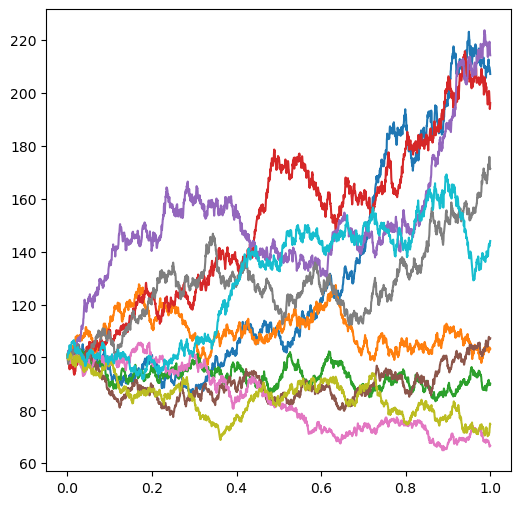

In [7]:
process = sps.simGeomBrownianMotion(meanRateOfReturn = 0.2,
                                   volatility = 0.3,
                                   initialPrice = 100.0)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process,ax)

plt.show()

Let $N(t)$ denote the Poisson process with intensity $\lambda$. By Theorem 11.2.3, for any partition $0 = t_0 < t_1 < \dotsb < t_n$, the increments
\begin{equation*}
N(t_1) - N(t_0), \dotsc, N(t_n) - N(t_{n-1})
\end{equation*}
are independent and
\begin{equation*}
P(\{N(t_{j+1}) - N(t_j) = k\}) = \frac{\lambda^k(t_{j+1}-t_j)^k}{k!} e^{-\lambda(t_{j+1} - t_j)}.
\end{equation*}
We will use this property to simulate the Poisson process.

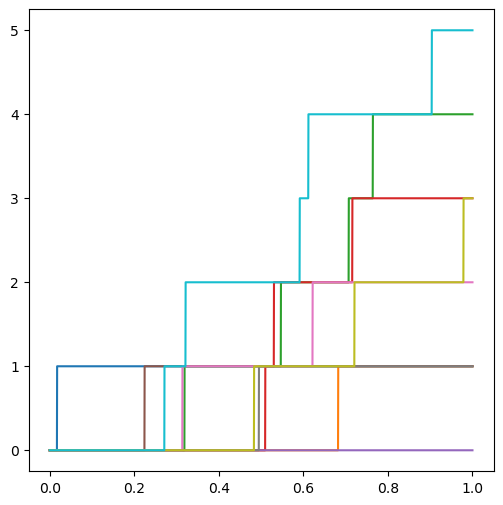

In [9]:
process = sps.simPoissonProcess(intensity= 2)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process, ax)

plt.show()

Let $N(t)$ be a Poisson process with intensity $\lambda$ and let $Y_1, Y_2, \dotsc$ be a sequence of independent and identically distributed random variables with mean $\beta = \mathbb{E}(Y_i)$. We define the compound Poisson process by
\begin{equation*}
Q(t) = \sum_{i=1}^{N(t)} Y_i.
\end{equation*}


Now suppose that, for each $i$, $Y_i$ takes on finitely many values $y_1, \dotsc, y_M$ and let $p(y_m) = P(\{Y_i = y_m\})$. By Corollary 11.3.4,
\begin{equation*}
N(t) = \sum_{m=1}^M N_m(t) \hspace{10pt} \text{ and } \hspace{10pt} Q(t) = \sum_{m=1}^M y_m N_m(t)
\end{equation*}
where $N_1, \dotsc, N_m$ are independent Poisson processes and each $N_m$ has intensity $\lambda p(y_m)$.

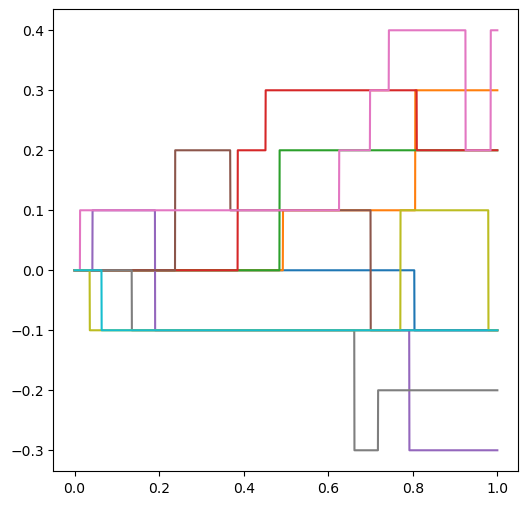

In [11]:
process = sps.simCompoundPoissonProcess(intensity = 2,
                                        jumps = [-0.2,-0.1,0.1,0.2],
                                        jumpProbabilities = [0.25,0.25,0.25,0.25])

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process, ax)

plt.show()

We simulate an asset driven by a Poisson Process. The asset price
\begin{equation*}
S(t) = S(0) e^{(\alpha - \lambda \sigma)t} (\sigma+1)^{N(t)}
\end{equation*}
is the solution to the stochastic differential equation
\begin{equation*}
d S(t) = \alpha S(t) \,dt + \sigma S(t-) \,dM(t),
\end{equation*}
N(t) is a Poisson process with intensity $\lambda > 0$ and $M(t) = N(t) - \lambda t$.

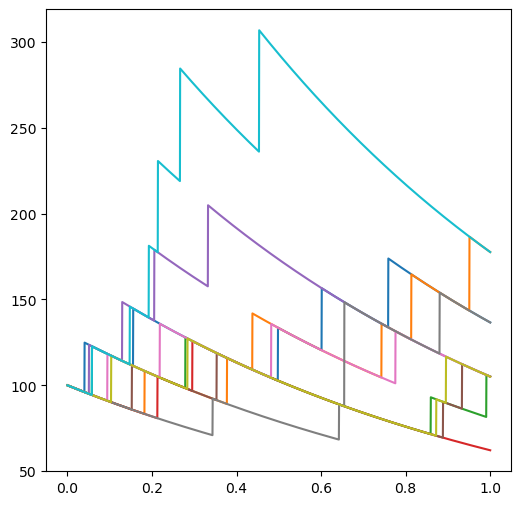

In [13]:
process = sps.assetModel1(meanRateOfReturn = 0.2,
                          volatility = 0.3,
                          intensity = 4.0,
                          initialPrice = 100.0)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process, ax)

plt.show()

We simulate an asset using the jump diffusion model. Let $\lambda_1, \dotsc, \lambda_M$ be positive numbers and let $-1 < y_1 < \dotsb < y_M$ be nonzero numbers. Let $W(t)$ be a Brownian motion process and $Q(t) = \sum_{i=1}^{M} y_m N_m(t)$ be a compound Poisson process with intensity $\lambda = \sum_{m=1}^M \lambda_m$, where $N_1(t), \dotsc, N_m(t)$ are independent Poisson processes with intensities $\lambda_1, \dotsc, \lambda_m$. Set
\begin{equation*}
\beta = \frac{1}{\lambda} \sum_{m=1}^M \lambda_m y_m = \sum_{m=1}^M P(\{Y_i = y_m\}) y_m.
\end{equation*}
The stock price is modeled by the stochastic differential equation
\begin{equation*}
dS(t) = (\alpha - \beta \lambda)S(t) \, dt + \sigma S(t) \, dW(t) + S(t-)\, dQ(t).
\end{equation*}
By Theorem 11.7.3, the solution to this stochastic differential equation is
\begin{equation*}
S(t)=S(0)\text{exp}\biggl\{\sigma W(t) + \left( \alpha - \beta\lambda -\frac{1}{2}\sigma^2\right) t \biggr\} \prod_{i=1}^{N(t)}(Y_i+1).
\end{equation*}

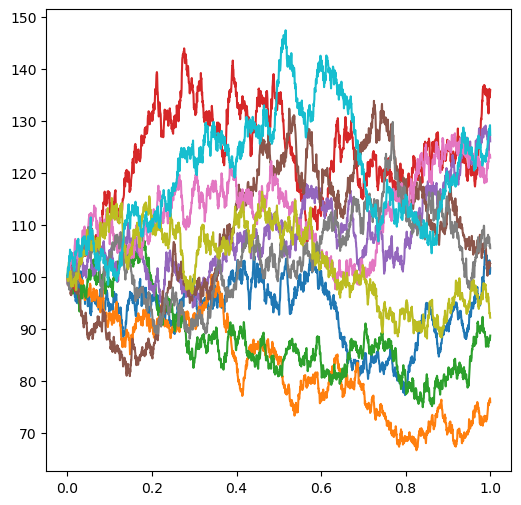

In [15]:
process = sps.assetModel2(meanRateOfReturn = 0.2,
                          volatility = 0.3,
                          intensity = 2.0,
                          jumps = [-0.02,-0.01,0.01,0.02],
                          jumpProbabilities = [0.25,0.25,0.25,0.25],
                          initialPrice = 100.0)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process, ax)

plt.show()

### Call Option Price Models and Hedging Strategies

In [17]:
interestRate = 0.01

ss = StrategySimulation(expirationTime = t,
                        numOfSims = nSims,
                        numOfSteps = nSteps,
                        interestRate = interestRate)

We consider a call option of an underlying stock with strike price $K$ and expiration time $T$.
Let $c(t,x)$ denote the value of the call option at time $t$ when the price of the underlying stock is $x$ at time $t$.
For a stock modeled by the geometric Brownian motion, the call option price is $c(t,x) = \kappa(T-t,x)$ where $\kappa(\tau,x)$ is
\begin{equation*}
\kappa(\tau,x) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^\infty e^{-r\tau} \left ( x e^{-\sigma \sqrt{\tau}y + (r-\frac{1}{2}\sigma^2)\tau} - K \right )^+ e^{-\frac{1}{2}y^2} \,dy.
\end{equation*}
Set
\begin{equation*}
d(\tau,x) = \frac{\log(x/K) + (r-\frac{1}{2}\sigma^2)\tau}{\sigma \sqrt{\tau}}.
\end{equation*}
Then, (see Exercise 4.9)
\begin{equation*}
\kappa (\tau,x) = x\frac{1}{\sqrt{2\pi}} \int_{-\infty}^{d(\tau,x) + \sigma \sqrt{\tau}}  e^{-\frac{1}{2}y^2}  \,dy - e^{-r\tau}K\frac{1}{\sqrt{2\pi}} \int_{-\infty}^{d(\tau,x)}  e^{-\frac{1}{2}y^2}  \,dy
\end{equation*}
and
\begin{equation*}
\kappa_x(\tau,x) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{d(\tau,x) + \sigma \sqrt{\tau}}  e^{-\frac{1}{2}y^2}  \,dy.
\end{equation*}


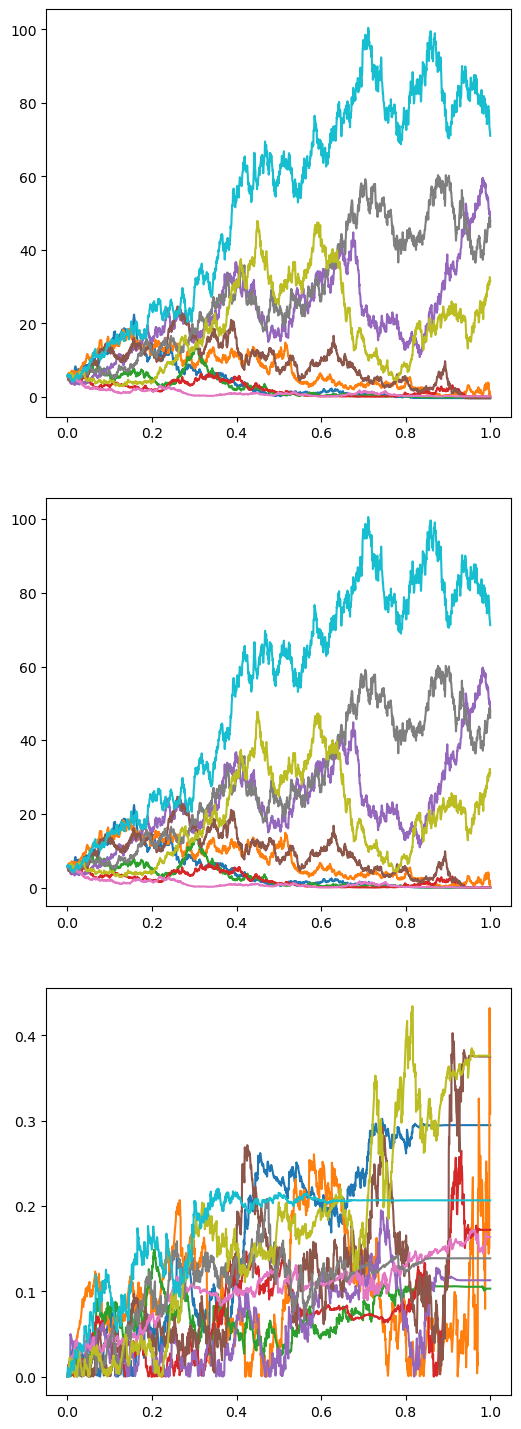

In [46]:
process = sps.simGeomBrownianMotion(meanRateOfReturn = 0.2,
                                    volatility = 0.3,
                                    initialPrice = 100.0)

optionPrice = ss.kappa(process, 120, 0.3)


vals = ss.calculateDiscountedPortfolioValues(optionPrice[:,0],process,ss.delta(process,120,0.3))


discountedOptionPrice = optionPrice * np.broadcast_to(np.exp(-interestRate * ss.times), (nSims,nSteps+1))

fig, ax = plt.subplots(3, 1, figsize=(6, 18))


ss.plotSimulation(vals, ax[0])
ss.plotSimulation(discountedOptionPrice, ax[1])
ss.plotSimulation(np.abs(vals - discountedOptionPrice), ax[2])


plt.show()